In [10]:
import os

dataset_path = "../dataset/for-2sec/for-2seconds"

print("Dataset exists:", os.path.exists(dataset_path))
print("Folders:", os.listdir(dataset_path))

Dataset exists: True
Folders: ['testing', 'training', 'validation']


In [11]:
import os

train_path = "../dataset/for-2sec/for-2seconds/training"

print("Classes:", os.listdir(train_path))

Classes: ['fake', 'real']


In [12]:
import os

fake_path = "../dataset/for-2sec/for-2seconds/training/fake"
real_path = "../dataset/for-2sec/for-2seconds/training/real"

print("Fake samples:", len(os.listdir(fake_path)))
print("Real samples:", len(os.listdir(real_path)))

Fake samples: 6978
Real samples: 6978


In [16]:
import os

fake_path = "../dataset/for-2sec/for-2seconds/training/fake"
real_path = "../dataset/for-2sec/for-2seconds/training/real"

sample_fake = os.listdir(fake_path)[0]
sample_real = os.listdir(real_path)[0]

print("Fake example:", sample_fake)
print("Real example:", sample_real)

Fake example: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
Real example: file1000.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav


In [14]:
import librosa

audio_path = fake_path + "/" + sample_fake

audio, sr = librosa.load(audio_path, sr=None)

print("Sample Rate:", sr)
print("Audio Shape:", audio.shape)
print("Duration (seconds):", len(audio)/sr)

Sample Rate: 16000
Audio Shape: (32000,)
Duration (seconds): 2.0


In [15]:
import sys
print(sys.executable)

c:\Users\khush\AppData\Local\Programs\Python\Python312\python.exe


Matplotlib is building the font cache; this may take a moment.


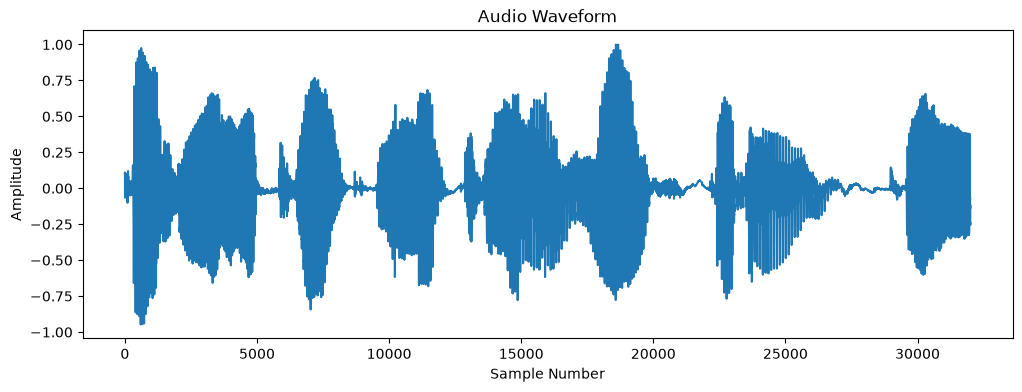

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(audio)
plt.title("Audio Waveform")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.show()

In [19]:
import librosa

mfccs = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print("MFCC Shape:", mfccs.shape)

MFCC Shape: (13, 63)


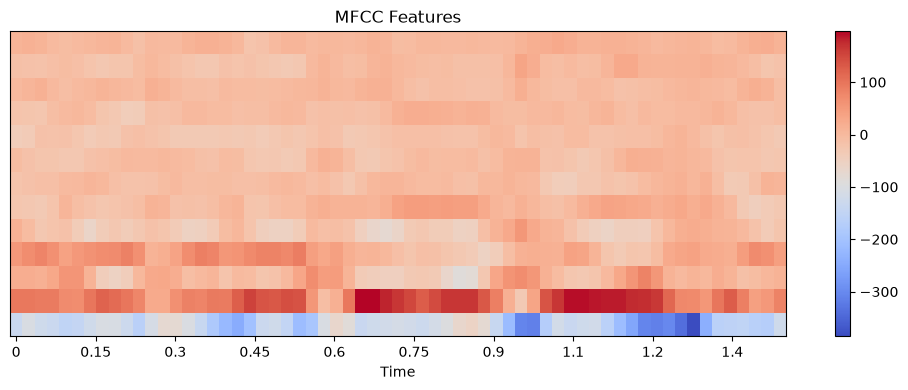

In [20]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfccs,
    x_axis="time"
)

plt.colorbar()
plt.title("MFCC Features")
plt.tight_layout()
plt.show()

In [22]:
def extract_mfcc(file_path, n_mfcc=13):
    audio, sr = librosa.load(file_path, sr=None)

    mfccs = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc
    )

    return mfccs

In [23]:
test_mfcc = extract_mfcc(audio_path)

print("MFCC Shape:", test_mfcc.shape)

MFCC Shape: (13, 63)


In [24]:
import numpy as np

mfcc_features = np.mean(test_mfcc, axis=1)

print("Feature Shape:", mfcc_features.shape)
print(mfcc_features)

Feature Shape: (13,)
[-160.22615     110.549904      3.4006608    29.77525     -22.197502
    5.079079     -7.7136884    -9.492633    -18.148422     -4.383947
   -0.68417925   -5.195248      5.518296  ]


In [27]:
import numpy as np
import librosa

def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=None)

    # MFCC
    mfccs = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )
    mfccs_mean = np.mean(mfccs, axis=1)

    # Zero Crossing Rate
    zcr = np.mean(librosa.feature.zero_crossing_rate(audio))

    # Spectral Centroid
    spectral_centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )
    )

    # RMS Energy
    rms = np.mean(
        librosa.feature.rms(y=audio)
    )

    features = np.hstack([
        mfccs_mean,
        zcr,
        spectral_centroid,
        rms
    ])

    return features

In [28]:
features = extract_features(audio_path)

print("Feature Shape:", features.shape)
print(features)

Feature Shape: (16,)
[-1.60226151e+02  1.10549904e+02  3.40066075e+00  2.97752495e+01
 -2.21975021e+01  5.07907915e+00 -7.71368837e+00 -9.49263287e+00
 -1.81484222e+01 -4.38394690e+00 -6.84179246e-01 -5.19524813e+00
  5.51829576e+00  9.13163442e-02  1.41365398e+03  2.02408239e-01]


In [29]:
fake_audio = fake_path + "/" + sample_fake
real_audio = real_path + "/" + sample_real

fake_features = extract_features(fake_audio)
real_features = extract_features(real_audio)

print("Fake Features:")
print(fake_features)

print("\nReal Features:")
print(real_features)

Fake Features:
[-1.60226151e+02  1.10549904e+02  3.40066075e+00  2.97752495e+01
 -2.21975021e+01  5.07907915e+00 -7.71368837e+00 -9.49263287e+00
 -1.81484222e+01 -4.38394690e+00 -6.84179246e-01 -5.19524813e+00
  5.51829576e+00  9.13163442e-02  1.41365398e+03  2.02408239e-01]

Real Features:
[-2.51625900e+02  6.17248383e+01  1.94407730e+01 -7.92448092e+00
 -4.04123917e+01 -1.19074373e+01 -1.72500038e+01 -2.47221184e+01
 -7.97992086e+00 -9.21217346e+00 -2.89585304e+01  2.41175368e-01
 -5.11697292e+00  2.59990389e-01  2.64664166e+03  7.62538612e-02]


In [30]:
features_list = []
labels = []

In [31]:
fake_files = os.listdir(fake_path)[:50]

for file in fake_files:

    file_path = os.path.join(fake_path, file)

    try:
        features = extract_features(file_path)

        features_list.append(features)
        labels.append(0)      # fake

    except Exception as e:
        print("Error:", file, e)

In [32]:
real_files = os.listdir(real_path)[:50]

for file in real_files:

    file_path = os.path.join(real_path, file)

    try:
        features = extract_features(file_path)

        features_list.append(features)
        labels.append(1)      # real

    except Exception as e:
        print("Error:", file, e)

In [33]:
print("Samples:", len(features_list))
print("Labels:", len(labels))

Samples: 100
Labels: 100


In [35]:
import pandas as pd

In [36]:
X = pd.DataFrame(features_list)

X["label"] = labels

print(X.shape)

X.head()

(100, 17)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,label
0,-160.226151,110.549904,3.400661,29.775249,-22.197502,5.079079,-7.713688,-9.492633,-18.148422,-4.383947,-0.684179,-5.195248,5.518296,0.091316,1413.653976,0.202408,0
1,-191.912155,151.461517,-22.587339,53.016319,-28.707859,-1.805478,-3.860579,-25.361650,-14.142918,-26.234634,-5.722347,-11.471427,-13.953784,0.091309,1021.408750,0.196030,0
2,-180.022049,160.632904,-48.394081,42.941128,-33.456379,-7.420874,-5.236178,-32.332783,-1.836682,-13.525933,-10.951509,-7.259015,-11.301181,0.098989,1172.010431,0.168117,0
3,-93.181351,72.160637,4.790507,9.141892,-10.425880,1.798548,-15.119717,2.731802,-11.086993,-9.293479,-9.568121,-2.643466,-6.159426,0.178595,2207.306688,0.226625,0
4,-157.638397,119.544861,8.581039,28.963230,2.968882,16.021814,-9.135882,3.364079,-6.400713,-1.367000,-12.176396,4.386896,-18.610542,0.127534,1385.707272,0.147649,0


In [37]:
X_features = X.drop("label", axis=1)
y = X["label"]

print(X_features.shape)
print(y.shape)

(100, 16)
(100,)


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80, 16)
(20, 16)


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [40]:
y_pred = rf.predict(X_test)

print(y_pred)

[1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 1]


In [41]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.95


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0]
 [ 1  9]]


In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

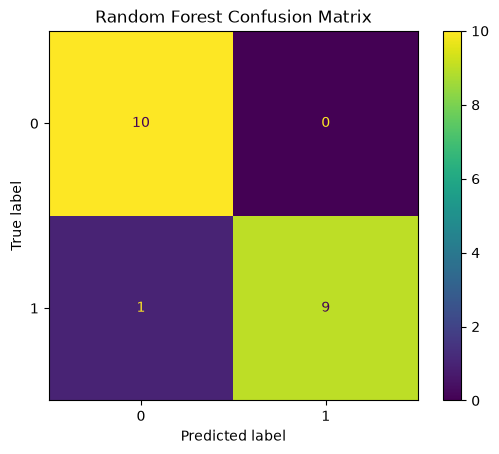

In [45]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [46]:
feature_names = []

for i in range(13):
    feature_names.append(f"MFCC_{i+1}")

feature_names.extend([
    "ZCR",
    "Spectral_Centroid",
    "RMS"
])

print(feature_names)

['MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7', 'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13', 'ZCR', 'Spectral_Centroid', 'RMS']


In [47]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
5,MFCC_6,0.119512
11,MFCC_12,0.109390
1,MFCC_2,0.078086
15,RMS,0.077462
13,ZCR,0.076237
12,MFCC_13,0.070399
9,MFCC_10,0.064782
14,Spectral_Centroid,0.060185
10,MFCC_11,0.058333
0,MFCC_1,0.048705


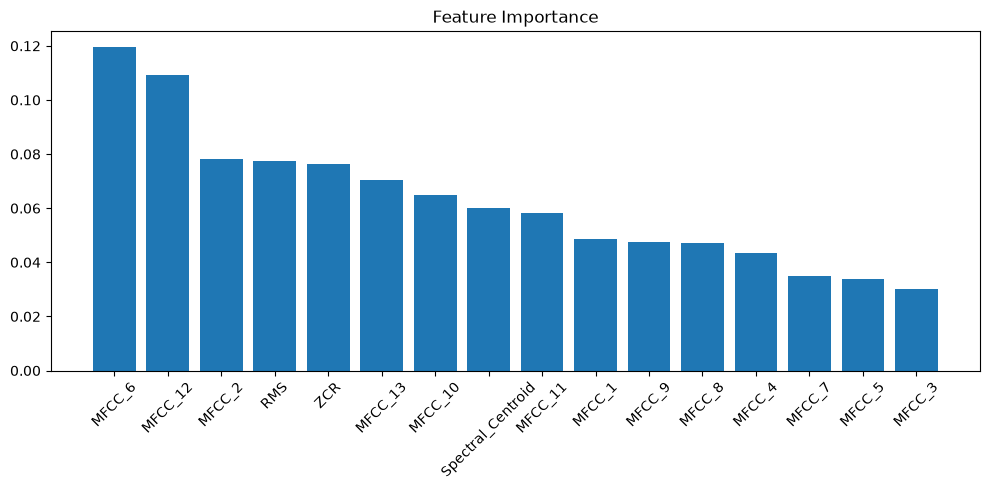

In [48]:
plt.figure(figsize=(10,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()